# CNMFe extraction diagnostics — a library of things to investigate

When the extracted footprints / traces look off, the question is *what kind of
off?*. Each section below shows one diagnostic view and explains what a
healthy vs unhealthy version of it looks like. Run **Setup** first, then jump
into whichever sections you need — each is independent.

**Inputs:**
- `RESULTS_DIR` — output of `model.save(...)` (manifest + A/C/S/YrA/g/sn).
- `MOVIE_ZARR` *(optional, several sections need it)* — the same
  `(T, H, W)` zarr you ran extraction on. If the recording was cropped
  (`model.cutout` is set), the cutout is applied automatically before
  computing mean / max / CORR / PNR images so views line up with `model.dims`.

Sections marked **[movie required]** are skipped if `MOVIE_ZARR is None`.

End of notebook: **Z. Cheat sheet** — symptom → most likely cause → knob to
try → which section to look at.

## Setup

Load the saved model + (optionally) the underlying movie. All later sections
build on the variables defined here (`model`, `params`, `A_dense`,
`mean_img_cutout`, `max_img_cutout`).

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('/home/fs539/code/simpler_cnmfe')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from cnmfe.pipeline import CNMFe
from cnmfe.io import open_zarr

# --- EDIT ME -----------------------------------------------------------------
RESULTS_DIR = Path('/home/fs539/code/simpler_cnmfe/tmp/cutout_analysis')
MOVIE_ZARR  = Path('/media/server/archive/projects/2023_intercontext/ToneComparison/data/1_preprocessed/20260520_m0010798_wt_1051/miniscope_video/mc_detrended.zarr')
# Set MOVIE_ZARR = None to skip the [movie required] sections.
# -----------------------------------------------------------------------------

model  = CNMFe.load(RESULTS_DIR)
params = model.params

hc, wc = model.dims
Kc = model.A.shape[1]
T  = model.C.shape[1]
A_dense = np.asarray(model.A.todense()).reshape(hc, wc, Kc)
peaks   = A_dense.reshape(-1, Kc).max(0)

print(f'model loaded from {RESULTS_DIR}')
print(f'  K={Kc}   dims={model.dims}   T={T}')
print(f'  accepted: {int(model.accepted_mask.sum()) if model.accepted_mask is not None else Kc}/{Kc}')
print(f'  cutout : {model.cutout}')

# Optional: load movie and pre-compute strided mean + max projections of the
# cutout slice (so the spatial views line up with A_dense / model.dims).
mean_img_cutout = max_img_cutout = movie_zarr = movie_slice_strided = None
if MOVIE_ZARR is not None and Path(MOVIE_ZARR).exists():
    movie_zarr = open_zarr(MOVIE_ZARR)
    print(f'movie : {movie_zarr.shape}  dtype={movie_zarr.dtype}  chunks={movie_zarr.chunks}')
    if model.cutout is not None:
        y0, y1, x0, x1 = model.cutout['bbox']
        t0, t1 = model.cutout['t_range']
    else:
        y0, y1 = 0, movie_zarr.shape[1]
        x0, x1 = 0, movie_zarr.shape[2]
        t0, t1 = 0, movie_zarr.shape[0]

    # Strided sample of ~500 frames is enough for mean / max projections.
    stride = max(1, (t1 - t0) // 500)
    movie_slice_strided = np.asarray(
        movie_zarr[t0:t1:stride, y0:y1, x0:x1], dtype=np.float32
    )
    mean_img_cutout = movie_slice_strided.mean(0)
    max_img_cutout  = movie_slice_strided.max(0)
    print(f'cutout sample: {movie_slice_strided.shape} (strided by {stride})')
else:
    print('MOVIE_ZARR not set — [movie required] sections will be skipped.')

model loaded from /home/fs539/code/simpler_cnmfe/tmp/cutout_analysis
  K=280   dims=(180, 180)   T=22439
  accepted: 272/280
  cutout : {'orig_dims': [300, 300], 'orig_T': 37398, 'bbox': [60, 240, 60, 240], 't_range': [7479, 29918], 'masked': False, 'spatial_mask_path': None}
movie : (37398, 300, 300)  dtype=float32  chunks=(1000, 300, 300)
cutout sample: (510, 180, 180) (strided by 44)


## A. Per-component footprint panel grid

**What it shows:** the top-N components (ranked by peak intensity) as small
heatmaps cropped tight around each component's centroid. Title:
`k<id>  n<npix>  e<eccentricity>`.

**This is usually the first thing to look at.** The section-7 contour plot
in the extraction notebook collapses each footprint to a single 30 %-of-peak
line, which makes very different shape failures look similar.

**Shape → what it means:**

| Panel shape | What it means | Knob to try |
|---|---|---|
| Roundish, soma-sized bright blob | Healthy. Single neuron well-isolated. | — |
| **Two or more bright peaks** | `sigma` too large → seed-suppression disk (≥ `2σ+1` px floor) wipes neighbours → LASSO grows one footprint to cover several cells. | drop `sigma`; lower `min_pnr` to allow more seeds |
| Soft amoeba blob extending to crop edge | Halo dominated. `spatial_max_thr` is too low or background isn't catching residual drift. | `spatial_max_thr` 0.1→0.25, `global_bg_rank` 0→1 |
| Hollow ring / donut | Ring background ate the soma. Either the ring radius is too small, or a strong global signal is leaking through. | `ring_size_factor` 1.5→1.2, `ring_constrain_sum=True` |
| Crescent / arc | Footprint sits on the edge of a neighbouring cell that the ring background partially subtracted. Usually pairs with multi-peak elsewhere. | drop `sigma` (root cause); `spatial_circular_max_dist_factor` 1.5→1.0 |
| Elongated streak | Vasculature contamination, or two adjacent neurons unsplit. | `spatial_circular_max_dist_factor` 1.5→1.0 |
| Tiny / fragmented dots | `min_pixel` too low or `spatial_close_radius=0`. | `min_pixel` 3→25 |
| Circle with a hard outer edge | `circular_constraint` is clipping (the cell or background extends past the circle). | raise `spatial_circular_max_dist_factor` |

The **median npix** printed below is the single best summary stat. For a
2 σ disk the expected area is `π·(2σ)²` pixels (e.g. 314 at σ=5,
113 at σ=3). Median *much* larger than that → halo or multi-cell.

In [ ]:
N_SHOW = 64                                  # top-N by peak; raise to inspect more
CROP_R = max(8, int(3 * params.sigma))       # half-side of per-component crop window

from scipy.ndimage import center_of_mass
from cnmfe._utils import footprint_center
order = np.argsort(-peaks)[:min(N_SHOW, Kc)]

stats = []
for k in order:
    fp = A_dense[..., k]
    nz = fp > 0
    npix = int(nz.sum())
    if npix == 0:
        stats.append((k, 0, 0.0, 0.0, (hc // 2, wc // 2))); continue
    # Centre the crop on the algorithm's argmax centre (the COM drifts off the
    # cell for haloed / multi-peak footprints, pushing the soma to the crop edge).
    cy, cx = footprint_center(fp)
    ys, xs = np.where(nz)
    if ys.size >= 2:
        cov = np.cov(np.vstack([ys, xs]))
        eig = np.linalg.eigvalsh(cov)
        ecc = float(np.sqrt(max(0.0, 1 - eig.min() / max(eig.max(), 1e-9))))
    else:
        ecc = 0.0
    stats.append((k, npix, float(fp.max()), ecc, (cy, cx)))

ncols = 8
nrows = int(np.ceil(len(stats) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(1.5 * ncols, 1.7 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, (k, npix, pk, ecc, (cy, cx)) in zip(axes, stats):
    y0p = max(0, cy - CROP_R); y1p = min(hc, cy + CROP_R + 1)
    x0p = max(0, cx - CROP_R); x1p = min(wc, cx + CROP_R + 1)
    ax.imshow(A_dense[y0p:y1p, x0p:x1p, k], cmap='magma',
              vmin=0, vmax=max(pk, 1e-9))
    ax.set_title(f'k{k} n{npix} e{ecc:.2f}', fontsize=7)
    ax.axis('off')
for ax in axes[len(stats):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

all_npix = np.array([(A_dense[..., k] > 0).sum() for k in range(Kc)])
expected_npix = int(np.pi * (2 * params.sigma) ** 2)
print(f'#components: {Kc}')
print(f'median footprint area: {int(np.median(all_npix))} px  '
      f'(expected ~{expected_npix} px for 2σ disk; σ={params.sigma})')
print(f'mean / max area      : {all_npix.mean():.0f} / {all_npix.max()} px')

## B. Footprint vs mean image vs max projection — *[movie required]*

**What it shows:** for the top-N components, three side-by-side crops:
1. **Footprint** (`A[..., k]`) — what extraction thinks the cell looks like.
2. **Mean image** of the cutout at the same crop — is there actually a
   bright soma there?
3. **Max projection** of a strided sample at the same crop — the upper
   envelope of what LASSO actually saw during firing events. A real neuron
   shows up as a bright disk here even if it's dim in the mean image.

**Look for:**
- Footprint blob aligns with bright spot in mean **and** max → real cell.
- Footprint contains **multiple** bright spots in mean/max → multi-cell
  (σ too large, see section A).
- Footprint sits on a dark area in **both** mean and max → ghost component
  (raise `min_pnr` or filter by `accepted_mask`).
- Footprint covers a vessel-shaped streak in mean → vasculature
  contamination (tighten `spatial_circular_max_dist_factor`).
- Max projection is much brighter than mean *with* footprint not centred on
  the brightest pixel → the soma is being grabbed by a neighbouring
  component.

In [ ]:
if mean_img_cutout is None:
    print('Skipping section B — MOVIE_ZARR not loaded.')
else:
    from cnmfe._utils import footprint_center
    N_SHOW_B = 12
    CROP_R_B = max(8, int(3 * params.sigma))
    order_b = np.argsort(-peaks)[:min(N_SHOW_B, Kc)]

    fig, axes = plt.subplots(N_SHOW_B, 3, figsize=(7, 2.1 * N_SHOW_B))
    for j, k in enumerate(order_b):
        fp = A_dense[..., k]
        # argmax centre (see section A) so the soma is centred in the crop.
        cy, cx = footprint_center(fp) if (fp > 0).any() else (hc // 2, wc // 2)
        y0p = max(0, cy - CROP_R_B); y1p = min(hc, cy + CROP_R_B + 1)
        x0p = max(0, cx - CROP_R_B); x1p = min(wc, cx + CROP_R_B + 1)

        axes[j, 0].imshow(fp[y0p:y1p, x0p:x1p], cmap='magma')
        axes[j, 0].set_ylabel(f'k{k}', rotation=0, labelpad=18, fontsize=8)
        axes[j, 0].set_title('footprint' if j == 0 else '', fontsize=8)

        axes[j, 1].imshow(mean_img_cutout[y0p:y1p, x0p:x1p], cmap='gray')
        axes[j, 1].set_title('mean' if j == 0 else '', fontsize=8)

        axes[j, 2].imshow(max_img_cutout[y0p:y1p, x0p:x1p], cmap='gray')
        axes[j, 2].set_title('max proj' if j == 0 else '', fontsize=8)

        for ax in axes[j]:
            ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout(); plt.show()

## C. Population histograms (area, peak, eccentricity)

**What it shows:** three summary distributions over all components.

**Look for:**
- **Area peak near `π·(2σ)²`** → expected for healthy single-cell
  footprints (≈3×σ²). Median *much* larger → halo (section A) or
  multi-cell.
- **Area distribution bimodal** → mixture of clean components + halo/multi-cell
  blobs. Inspect each peak in section A separately.
- **Peak distribution bimodal** → likely real cells (high peak) + ghost
  components (low peak). Cross-check with `accepted_mask`; bump `min_pnr` if
  ghosts are accepted.
- **Eccentricity skewed > 0.8** → many elongated footprints. Likely cause:
  vasculature contamination, or two close cells in one footprint.

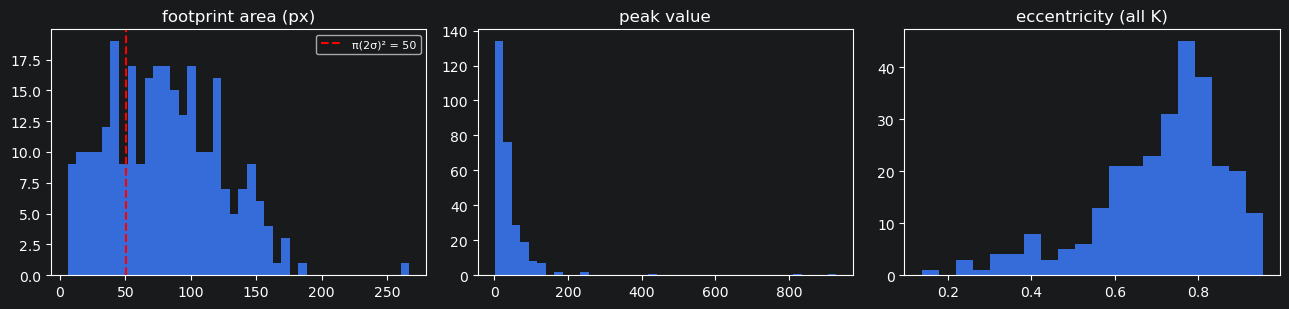

K = 280  (272 accepted by auto-eval)
area    median=78  mean=80  max=267
peak    median=26  max=928
ecc     median=0.75  share > 0.8: 30%


In [5]:
all_npix = np.array([(A_dense[..., k] > 0).sum() for k in range(Kc)])
all_pk = peaks

eccs = []
for k in range(Kc):
    nz = A_dense[..., k] > 0
    if nz.sum() < 2:
        eccs.append(0.0); continue
    ys, xs = np.where(nz)
    cov = np.cov(np.vstack([ys, xs]))
    eig = np.linalg.eigvalsh(cov)
    eccs.append(float(np.sqrt(max(0.0, 1 - eig.min() / max(eig.max(), 1e-9)))))
eccs = np.array(eccs)

expected_npix = np.pi * (2 * params.sigma) ** 2
fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
ax[0].hist(all_npix, bins=40)
ax[0].axvline(expected_npix, color='r', ls='--', label=f'π(2σ)² = {expected_npix:.0f}')
ax[0].set_title('footprint area (px)'); ax[0].legend(fontsize=8)
ax[1].hist(all_pk, bins=40); ax[1].set_title('peak value')
ax[2].hist(eccs, bins=20); ax[2].set_title('eccentricity (all K)')
plt.tight_layout(); plt.show()

acc = model.accepted_mask if model.accepted_mask is not None else np.ones(Kc, bool)
print(f'K = {Kc}  ({int(acc.sum())} accepted by auto-eval)')
print(f'area    median={np.median(all_npix):.0f}  mean={all_npix.mean():.0f}  max={all_npix.max():.0f}')
print(f'peak    median={np.median(all_pk):.3g}  max={all_pk.max():.3g}')
print(f'ecc     median={np.median(eccs):.2f}  share > 0.8: {(eccs > 0.8).mean()*100:.0f}%')

## D. Contour overlay on mean image — *[movie required]*

**What it shows:** 30 %-of-peak contour for every footprint drawn on the
cutout mean image (the same kind of plot as section 7 of the extraction
notebook, but standalone).

**Look for:**
- Tight contours hugging individual bright soma → healthy.
- Contours **tile the FOV** Voronoi-style with no dark gaps → over-segmentation
  / halo (section A).
- Contours **heavily overlap** → failed merge (section E will confirm).
- Many contours sitting on dark areas of the mean → ghost components
  (section C peak histogram will show a low-peak mode).

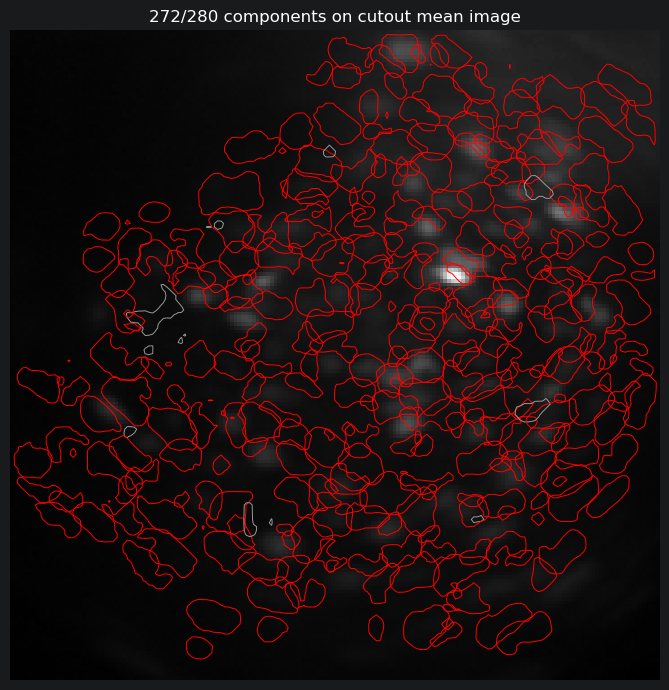

In [6]:
if mean_img_cutout is None:
    print('Skipping section D — MOVIE_ZARR not loaded.')
else:
    acc = model.accepted_mask if model.accepted_mask is not None else np.ones(Kc, bool)
    fig, ax = plt.subplots(1, 1, figsize=(7, 7))
    ax.imshow(mean_img_cutout, cmap='gray')
    for k in range(Kc):
        fp = A_dense[..., k]
        if fp.max() <= 0:
            continue
        ax.contour(fp, [fp.max() * 0.3],
                   colors='red' if acc[k] else '0.6',
                   linewidths=0.7)
    ax.set_title(f'{int(acc.sum())}/{Kc} components on cutout mean image')
    ax.axis('off'); plt.tight_layout(); plt.show()

## E. Pairwise spatial overlap + trace correlation matrices

**What it shows:** two K×K heatmaps.
1. **Jaccard overlap** of binary footprints. Diagonal masked.
2. **Pearson correlation** of temporal traces `C`. Diagonal masked.

The merge rule (`cnmfe/merging.py`) merges pair (i, j) when
`|trace_corr| > merge_thr_corr` **AND** `(Jaccard > merge_thr_overlap` OR
centres within `merge_centre_dist_factor · σ)`. So pairs that are bright in
**both** matrices should have been merged.

**Look for:**
- Almost-black off-diagonal in both → well-separated components, healthy.
- Bright off-diagonal in **trace corr only** → separate cells that fire
  together (e.g. coupled by a common input). Don't merge — their footprints
  are different. (This is also what happens after the rank-1 background
  doesn't fully absorb a population signal.)
- Bright off-diagonal in **both** → should have merged. Lower `merge_thr_corr`
  (0.85 → 0.75) and re-run. The cutout-analysis tuning block does this.
- Bright off-diagonal in **overlap only** → spatial neighbours with
  uncorrelated traces. Real, just close together. If many such pairs, your
  `dilation_radius` may be too generous (more crosstalk pixels in each
  LASSO active set).

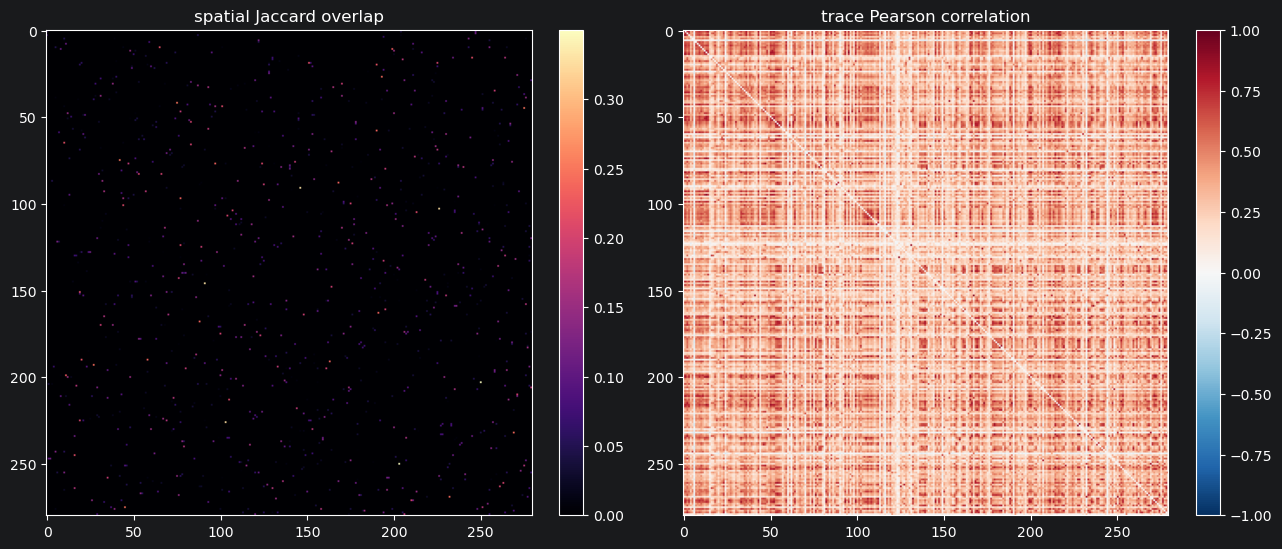

#pairs (i<j) with trace_corr > 0.85      : 84
#pairs (i<j) with jaccard    > 0.5      : 0
#pairs satisfying BOTH (should have merged): 0


In [7]:
A_bin = (A_dense.reshape(-1, Kc) > 0).astype(np.float32)
inter = A_bin.T @ A_bin
areas = A_bin.sum(0)
union = areas[:, None] + areas[None, :] - inter
jaccard = inter / np.maximum(union, 1.0)
np.fill_diagonal(jaccard, 0.0)

# np.corrcoef on (K, T) is K×K
trace_corr = np.corrcoef(model.C)
np.fill_diagonal(trace_corr, 0.0)

fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
im0 = ax[0].imshow(jaccard, cmap='magma', vmin=0, vmax=max(jaccard.max(), 0.1))
ax[0].set_title('spatial Jaccard overlap')
plt.colorbar(im0, ax=ax[0], fraction=0.046)
im1 = ax[1].imshow(trace_corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax[1].set_title('trace Pearson correlation')
plt.colorbar(im1, ax=ax[1], fraction=0.046)
plt.tight_layout(); plt.show()

mt = float(getattr(params, 'merge_thr_corr', 0.85))
mo = float(getattr(params, 'merge_thr_overlap', 0.5))
high_corr_pairs = int(((trace_corr > mt)).sum() // 2)
high_overlap_pairs = int(((jaccard > mo)).sum() // 2)
both = int((((trace_corr > mt) & (jaccard > mo))).sum() // 2)
print(f'#pairs (i<j) with trace_corr > {mt}      : {high_corr_pairs}')
print(f'#pairs (i<j) with jaccard    > {mo}      : {high_overlap_pairs}')
print(f'#pairs satisfying BOTH (should have merged): {both}')

## F. Trace gallery (top-N by amplitude)

**What it shows:** top-N components' `C + YrA` (gray, the noisy projected
trace) and `C` (blue, the OASIS-deconvolved trace) side by side.

**Look for:**
- **Sharp rise + clean exponential decay** in `C`, with `C + YrA` adding only
  noise around `C` → healthy calcium events.
- **`C` is square-wave / clipped flat at top** → OASIS over-smoothing
  (`g_prior_weight` too high or estimated `g` too close to 1). Lower
  `g_prior_weight` 0.7 → 0.3, or enable detrending if not already on.
- **`C` is flat zero while `C + YrA` looks like real bursts** → OASIS
  threshold killed everything (rare; usually means the `g` prior bumped `g`
  way above noise).
- **All components fire in lockstep** in the same frame ranges → global
  drift not removed. Enable per-pixel detrend (section 2b of the
  cutout-analysis notebook).
- **Slow monotonic ramp at the start of every trace** → LED warm-up
  bleeding through. Increase `temporal_crop` start to skip the warm-up
  window, or run detrend.
- **One trace is dominated by spikes that show up nowhere else** in nearby
  components → isolated, real cell. Good.

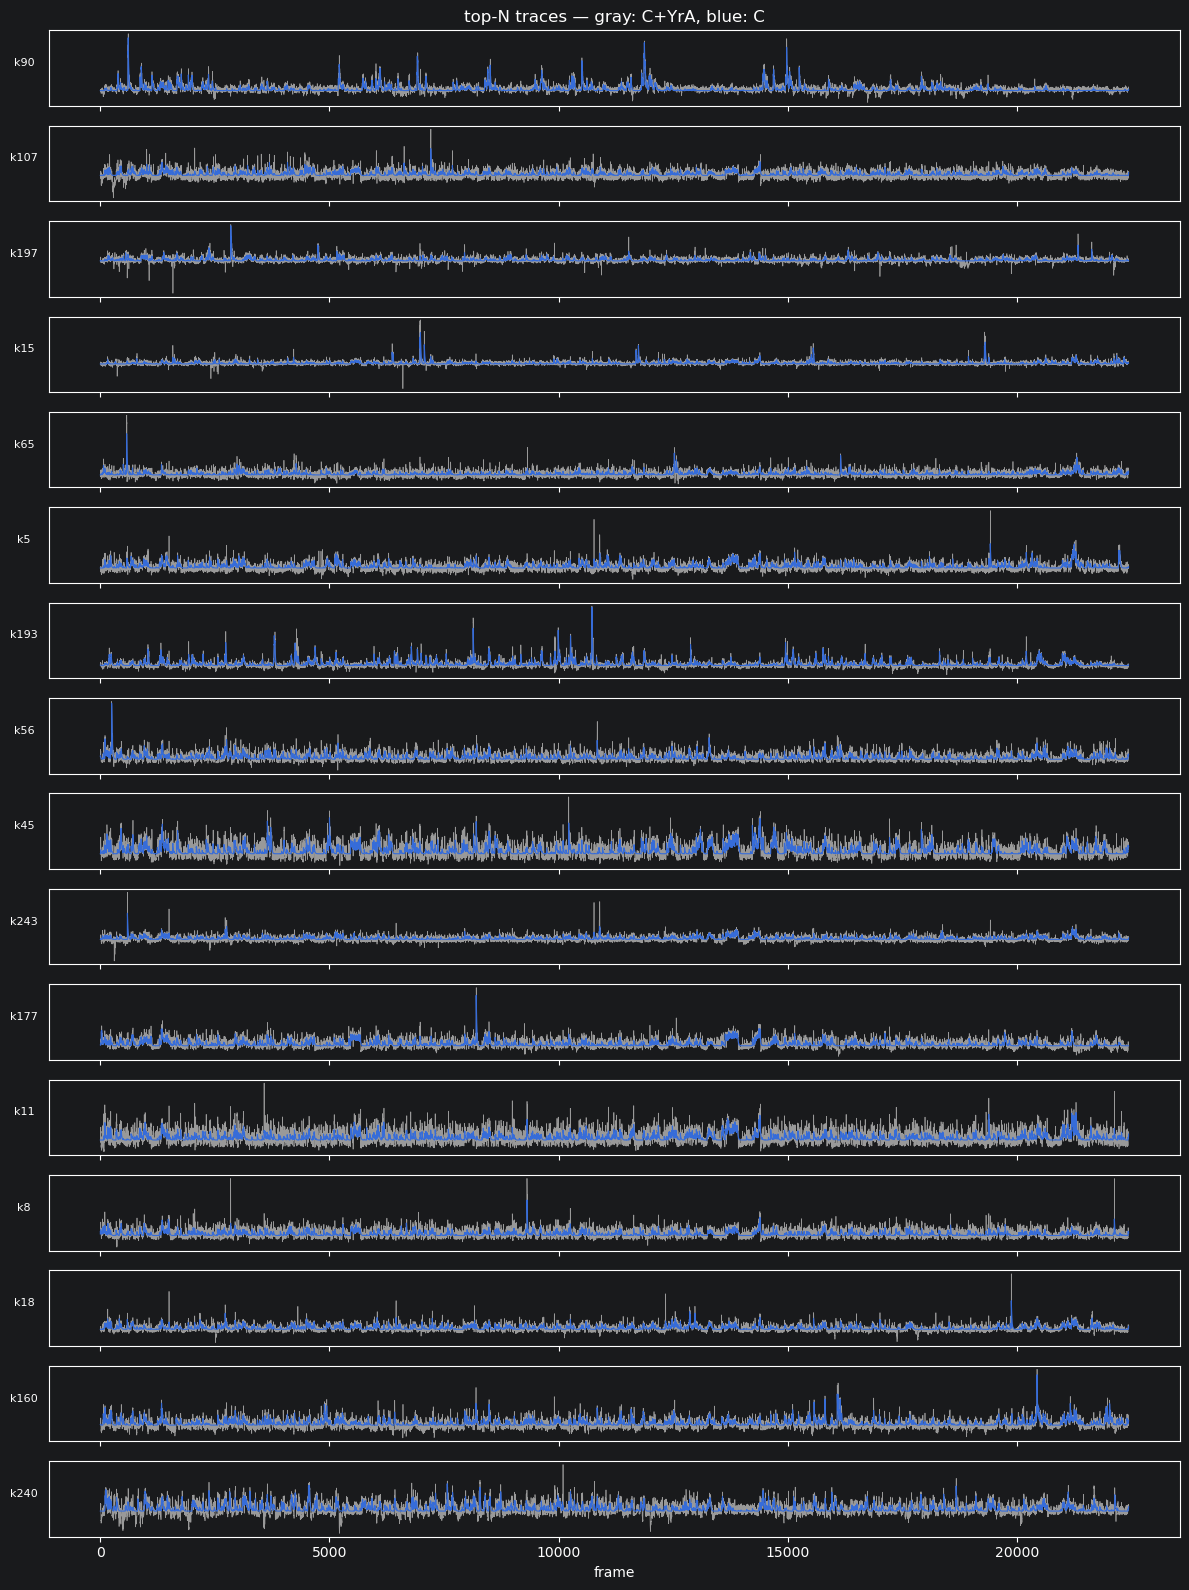

In [8]:
N_TRACE = 16
acc = model.accepted_mask if model.accepted_mask is not None else np.ones(Kc, bool)
pool = np.where(acc)[0]
pool = pool if pool.size else np.arange(Kc)
trace_amp = (model.C + model.YrA)[pool].max(1)
order_t = pool[np.argsort(-trace_amp)][:N_TRACE]

fig, axes = plt.subplots(N_TRACE, 1, figsize=(12, 1.0 * N_TRACE), sharex=True)
axes = np.atleast_1d(axes)
for ax, k in zip(axes, order_t):
    ax.plot(model.C[k] + model.YrA[k], color='0.6', lw=0.5)
    ax.plot(model.C[k], color='C0', lw=0.8)
    ax.set_ylabel(f'k{k}', rotation=0, labelpad=18, fontsize=8)
    ax.set_yticks([])
axes[0].set_title('top-N traces — gray: C+YrA, blue: C')
axes[-1].set_xlabel('frame')
plt.tight_layout(); plt.show()

## G. AR(1) decay-coefficient distribution

**What it shows:** per-component `g` (AR(1) coefficient used by OASIS) and,
if `params.frame_rate_hz` is set, the implied decay time
`τ = −1000 / (fps · ln g)` in ms.

The expected `τ` depends on the indicator and on the firing context. The
project's reference table (from `CLAUDE.md`):
GCaMP6f ~140, jGCaMP7f ~160, jGCaMP8f ~70, jGCaMP8m ~180, jGCaMP8s ~350,
GCaMP6s/7s ~1000 ms.

**Look for:**
- **Median near the expected indicator τ** with a moderate spread →
  healthy.
- **Long tail toward g = 1 / very long τ** → Yule-Walker contaminated by
  slow drift. Enable `ar_detrend_order=2` (`CNMFeParams`), or detrend the
  movie (section 2b of the cutout-analysis notebook).
- **All `g` clustered exactly at `g_target`** (red dashed line, if set) →
  `g_prior_weight` is too close to 1 — you've pinned `g` rather than
  shrunk to the prior. Lower `g_prior_weight` toward 0.3–0.5.
- **Distribution bimodal** → mixture of real cells (correct τ) and ghosts
  (random τ). Cross-check with `accepted_mask` / `auto_eval_snr_amp_thr`.

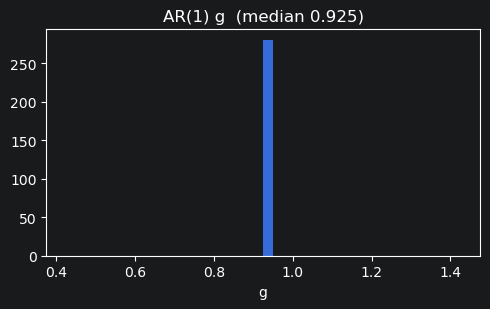

g     : median 0.925  share > 0.99: 0%


In [9]:
g_list = model.g
if g_list is None or len(g_list) == 0:
    print('model.g not stored — skipping section G.')
else:
    g_arr = np.array([float(np.atleast_1d(g)[0]) for g in g_list])
    fps = getattr(params, 'frame_rate_hz', None)
    decay_ms = getattr(params, 'decay_time_ms', None)

    fig, ax = plt.subplots(1, 2 if fps else 1, figsize=(10 if fps else 5, 3.2))
    if not fps:
        ax = [ax]
    ax[0].hist(g_arr, bins=40)
    ax[0].set_title(f'AR(1) g  (median {np.median(g_arr):.3f})')
    ax[0].set_xlabel('g')

    if fps:
        g_safe = np.clip(g_arr, 1e-6, 1 - 1e-6)
        tau_ms = -1000.0 / (fps * np.log(g_safe))
        ax[1].hist(tau_ms[np.isfinite(tau_ms)], bins=40)
        ax[1].set_title(f'decay τ (ms) — median {np.median(tau_ms):.0f}')
        ax[1].set_xlabel('τ ms')
        if decay_ms is not None:
            ax[1].axvline(decay_ms, color='r', ls='--',
                          label=f'prior target {decay_ms:.0f} ms')
            ax[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()

    print(f'g     : median {np.median(g_arr):.3f}  share > 0.99: {(g_arr > 0.99).mean()*100:.0f}%')
    if fps:
        print(f'τ ms : median {np.median(tau_ms):.0f}  iqr [{np.percentile(tau_ms,25):.0f}, {np.percentile(tau_ms,75):.0f}]')

## H. CORR / PNR maps — *[movie required]*

**What it shows:** local correlation (CORR) and peak-to-noise ratio (PNR)
images of the cutout. These are the inputs to greedy init — the seed
locations are local maxima of `CORR × PNR` above `(min_corr, min_pnr)`. The
third panel overlays each extracted component's centre on `CORR·PNR` with
**two estimators**:

- **cyan = `footprint_center`** (smoothed-argmax) — *the centre the algorithm
  itself uses* in `circular_constraint` / `merge_components`. This is where
  CNMFe actually thinks each cell is.
- **grey = centre-of-mass** of the binary footprint — the *old* overlay. For
  elongated / haloed / multi-peak footprints the COM drifts into the dim
  inter-cell space, so it misrepresents seed placement. Kept only for
  comparison. The printed `COM-vs-argmax drift` quantifies the gap.

**Read the two overlays together:**
- **cyan dots land on the bright `CORR·PNR` blobs, grey ones scattered into
  the gaps** → seed *placement* is fine; the "centroids miss the cells" look
  was a COM-overlay artifact. The real issue (if any) is footprint
  *over-extraction* — go to sections A/C/D and the cutout-analysis tightening
  block (`spatial_max_thr`, `spatial_circular_max_dist_factor`, `merge_thr_corr`).
- **even the cyan dots miss bright blobs / sit on dark areas** → the raw
  seeding is genuinely off. Cyan on dark `CORR·PNR` = ghost seeds (raise
  `min_corr` / `min_pnr`); bright blobs with no cyan dot = missed seeds
  (suppressed by neighbours when `sigma` is too large, or below threshold in
  the dim periphery — a vignetting bias, see `todo/vignetting_spatial_threshold.md`).
- **CORR map is uniformly bright everywhere** → unremoved global signal
  (bleach or LED flicker). Run detrending first.
- **CORR shows elongated blobs in concentric arcs around the centre** →
  radial illumination/vignetting structure, not cell layout; it inflates CORR
  in a ring and biases a single global `min_corr`/`min_pnr` (over-seed centre,
  under-seed periphery).

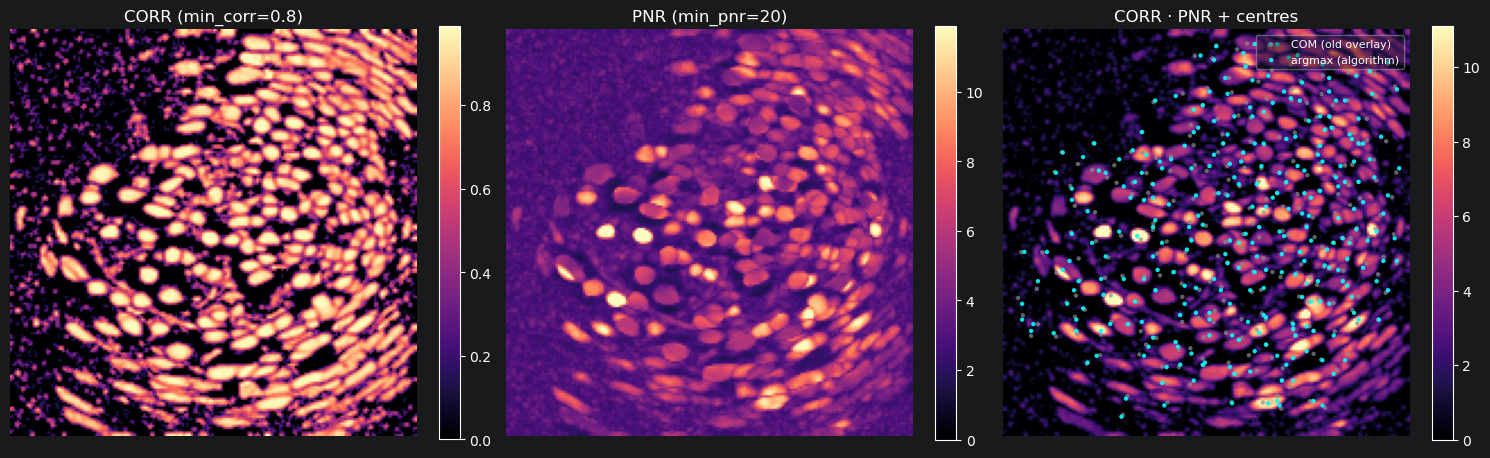

COM-vs-argmax centre drift over 280 comps: median 1.8 px  90th pct 3.2 px  (sigma=2.0)


In [14]:
if movie_slice_strided is None:
    print('Skipping section H — MOVIE_ZARR not loaded.')
else:
    from cnmfe.preprocess import correlation_pnr
    from cnmfe._utils import footprint_center
    # Use the same strided cutout slice we built in Setup.
    cn, pnr = correlation_pnr(
        movie_slice_strided,
        sigma=params.sigma,
        center_psf=getattr(params, 'center_psf', True),
        n_jobs=getattr(params, 'n_jobs', -1),
        stride=1,
    )
    seed_score = cn * pnr

    # Component centres, TWO estimators overlaid:
    #   * argmax (cyan) — the smoothed-argmax `footprint_center` the algorithm
    #     ITSELF uses in circular_constraint / merge_components. This is where
    #     CNMFe actually places each cell.
    #   * COM (grey)    — the old binary-mask centre-of-mass. For elongated /
    #     haloed / multi-peak footprints the COM drifts into the dim inter-cell
    #     space, so it MISREPRESENTS seed placement. Shown faint for comparison.
    # If the cyan dots sit on the bright CORR·PNR blobs but the grey ones don't,
    # the "centroids miss the cells" look is a COM artifact, not bad seeding.
    has_fp = peaks > 0
    centroids_arg = np.array([
        footprint_center(A_dense[..., k]) if has_fp[k] else [np.nan, np.nan]
        for k in range(Kc)
    ], dtype=float)
    centroids_com = np.array([
        list(center_of_mass(A_dense[..., k] > 0))
        if (A_dense[..., k] > 0).any() else [np.nan, np.nan]
        for k in range(Kc)
    ])

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    vmax_cn  = np.nanpercentile(cn, 99.5)
    vmax_pnr = np.nanpercentile(pnr, 99.5)
    vmax_sc  = np.nanpercentile(seed_score, 99.5)

    im = axes[0].imshow(cn,  cmap='magma', vmin=0, vmax=vmax_cn)
    axes[0].set_title(f'CORR (min_corr={params.min_corr})'); plt.colorbar(im, ax=axes[0], fraction=0.046)
    im = axes[1].imshow(pnr, cmap='magma', vmin=0, vmax=vmax_pnr)
    axes[1].set_title(f'PNR (min_pnr={params.min_pnr})'); plt.colorbar(im, ax=axes[1], fraction=0.046)
    im = axes[2].imshow(seed_score, cmap='magma', vmin=0, vmax=vmax_sc)
    axes[2].set_title('CORR · PNR + centres'); plt.colorbar(im, ax=axes[2], fraction=0.046)
    # COM first (faint, underneath), then argmax (cyan, on top).
    axes[2].scatter(centroids_com[:, 1], centroids_com[:, 0], s=10, c='0.55',
                    alpha=0.7, edgecolors='none', label='COM (old overlay)')
    axes[2].scatter(centroids_arg[:, 1], centroids_arg[:, 0], s=10, c='cyan',
                    alpha=0.9, edgecolors='none', label='argmax (algorithm)')
    leg = axes[2].legend(loc='upper right', fontsize=8, framealpha=0.4)
    for txt in leg.get_texts():
        txt.set_color('white')
    for ax in axes:
        ax.axis('off')
    Path('/home/fs539/code/simpler_cnmfe/live_runs/diagnostics_figs/').mkdir(parents=True, exist_ok=True)
    plt.savefig('./diagnostics_figs/corr_pnr_centroids.png', bbox_inches='tight')
    plt.tight_layout(); plt.show()

    # Quantify how far the COM drifts off the algorithm's argmax centre. A large
    # median drift (relative to sigma) means the cyan/grey split is the artifact:
    # the seeds are better placed than the old COM overlay suggested.
    valid = has_fp & np.isfinite(centroids_com[:, 0])
    if valid.any():
        drift = np.hypot(centroids_arg[valid, 0] - centroids_com[valid, 0],
                         centroids_arg[valid, 1] - centroids_com[valid, 1])
        print(f'COM-vs-argmax centre drift over {int(valid.sum())} comps: '
              f'median {np.median(drift):.1f} px  90th pct '
              f'{np.percentile(drift, 90):.1f} px  (sigma={params.sigma})')


## Z. Cheat sheet — symptom → most likely cause → knob → section to look at

| Symptom (what you see) | Most likely cause | Knob to try first | Inspect in |
|---|---|---|---|
| **Two or more bright peaks** in many footprints | `sigma` too large → seed-suppression disk wipes neighbours → LASSO merges them in space | `sigma` 5→3 (single biggest lever), also reduce `min_pnr` to let more seeds in | A, B, H |
| **Soft amoeba blobs** filling crop window, contours tile the FOV | Halo dominated; `spatial_max_thr` too low, residual background drift | `spatial_max_thr` 0.1→0.25; `global_bg_rank` 0→1; verify detrend ran (section J of `cutout_analysis.ipynb`) | A, C, D |
| **Donut / hollow ring** footprints | Ring background ate the soma | `ring_constrain_sum=True`; `ring_size_factor` 1.5→1.2 | A |
| **Crescent / arc** footprints | Asymmetric ring subtraction; usually paired with multi-peak failures elsewhere | Fix `sigma` first (root cause); then `spatial_circular_max_dist_factor` 1.5→1.0 | A, B |
| **Streaky / elongated** (ecc > 0.8 common) | Vasculature contamination, or two close neurons unsplit | `spatial_circular_max_dist_factor` 1.5→1.0 (clips tendrils); for vasculature, draw an ROI mask | A, C |
| **Many tiny / fragmented** dots | `min_pixel` too low; or `spatial_close_radius=0` so jagged LASSO supports split | `min_pixel` 3→25; ensure `spatial_close_radius=1` | A, C |
| **Hard circular outer boundary** on footprints (clipped circle) | `circular_constraint` cutoff too tight | raise `spatial_circular_max_dist_factor` (1.2→1.5→2.0) | A |
| **Heavy spatial + trace overlap** between pairs that didn't merge | `merge_thr_corr` too strict | `merge_thr_corr` 0.85→0.75 | E |
| **Ghost components** (cyan dots on dark areas in CORR·PNR; bimodal peak histogram) | `min_corr` / `min_pnr` too lax for this recording | raise `min_pnr` (10→15); auto-eval `accepted_mask` flags ghosts by SNR | C, H |
| **All traces fire in lockstep** in the same frame ranges | Global drift not removed (bleach, LED warm-up, focus step) | Run per-pixel detrend (section 2b of `cutout_analysis.ipynb`) | F, I |
| **Monotonic ramp at the start** of every trace | LED warm-up | Crop the first N frames via `temporal_crop`; or detrend | F |
| **Saturated / square-wave** `C` traces with normal `C + YrA` | OASIS over-smoothing; `g` pinned at the prior target | `g_prior_weight` 0.7→0.3; or unset `decay_time_ms` to use Yule-Walker only | F, G |
| **Long tail toward g → 1** in section G | Yule-Walker contaminated by drift | `ar_detrend_order=2`; or detrend the movie | G |
| **CORR map uniformly bright everywhere** | Unremoved global signal in the movie | Detrend the movie first | H |
| **Footprints clipped at crop border** | Real cells extend past the spatial crop | Expand `spatial_crop` to leave ≳ `max_shift` px margin around the ROI | D |

When in doubt: open section A (panel grid). Most mistakes are visible there
in seconds.